# AI-ML Assignment 3 - Salary Prediction using Polynomial Regression
Name: Adit Singh Rathore
Registration Number: 23BCE10238
Application No : IN26011049

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Position_Salaries.csv")
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


Input Feature: Level
Target Variable: Salary

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [3]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing

In [4]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [5]:
X = df[["Level"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((8, 1), (2, 1))

## Task 3: Model Development

In [6]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = model.predict(X_test_poly)
y_pred

array([606335.60051158,  84934.8912917 ])

## Task 4: Model Evaluation

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 70635.24590164163
MSE: 6263853282.860704
R2 Score: 0.8762695647829984


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


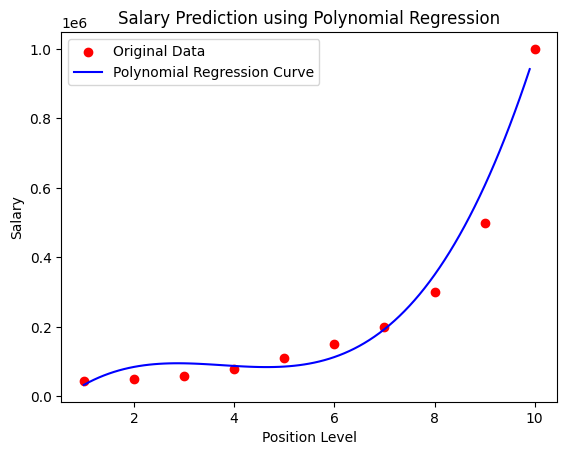

In [9]:
X_grid = np.arange(min(X["Level"]), max(X["Level"]), 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.scatter(X, y, color="red", label="Original Data")
plt.plot(X_grid, y_grid_pred, color="blue", label="Polynomial Regression Curve")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Salary Prediction using Polynomial Regression")
plt.legend()
plt.savefig("polynomial_regression_plot.png")
plt.show()

**Observations:**

1. Salary increases rapidly as the position level increases, especially at the highest levels. This is why a Polynomial Regression model fits the data better than a straight-line Linear Regression model.

2. Since the dataset contains only 10 records, the R² score is not very stable. The test set has only a few data points, so the evaluation results may vary and the prediction error can appear higher or lower.

3. The degree 3 polynomial curve passes very close to the original data points, showing that the model is able to capture the non-linear relationship between position level and salary effectively.


## Task 5: Conclusion

In this assignment, I used Polynomial Regression to predict an employee's salary based on their position level. The dataset contained only 10 records, but the relationship between position level and salary was clearly non-linear. Because of this, Linear Regression was not able to fit the data accurately.

Linear Regression fits a straight line to the data, while Polynomial Regression adds higher-degree terms (such as (x^2), (x^3), etc.) to create a curved model. This allows it to capture non-linear patterns more effectively.

In this dataset, salaries increase gradually at lower position levels but rise sharply at higher levels. Polynomial Regression is better suited for this type of relationship because it can model the rapid increase in salary more accurately than a simple linear model.

Overall, the Polynomial Regression model provides more accurate predictions for this dataset. However, since the dataset is very small, the model's ability to generalize to new data may be limited.
